Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1000 non-null   int64
 1   income            1000 non-null   int64
 2   employment_years  1000 non-null   int64
 3   loan_amount       1000 non-null   int64
 4   credit_score      1000 non-null   int64
 5   target            1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB

Описательная статистика:


,age,income,employment_years,loan_amount,credit_score,target
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,88926.725000,11.791000,24200.240000,578.899000,0.300000
std,14.99103,34764.870925,7.215496,14078.085778,160.306054,0.458487
min,18.00000,30060.000000,0.000000,1097.000000,300.000000,0.000000
25%,31.00000,58856.500000,5.000000,11997.250000,438.750000,0.000000
50%,44.00000,88066.500000,12.000000,23311.500000,582.000000,0.000000
75%,56.00000,117393.500000,18.000000,35622.500000,717.250000,1.000000
max,69.00000,149797.000000,24.000000,49998.000000,849.000000,1.000000


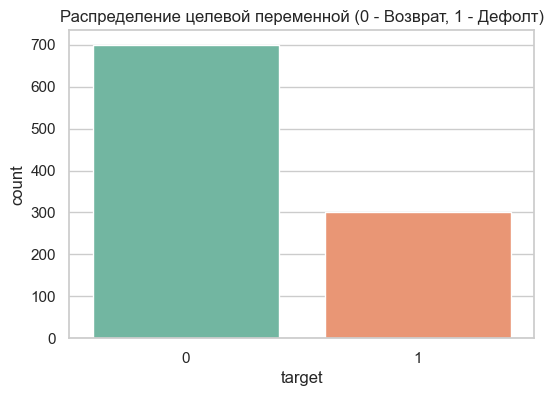

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

data_path = Path("../data/credit_risk_data.csv")
df = pd.read_csv(data_path)

print("Информация о датасете:")
df.info()

print("\nОписательная статистика:")
display(df.describe())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Распределение целевой переменной (0 - Возврат, 1 - Дефолт)')

artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(artifacts_dir / "target_distribution.png", bbox_inches='tight', dpi=300)

plt.show()

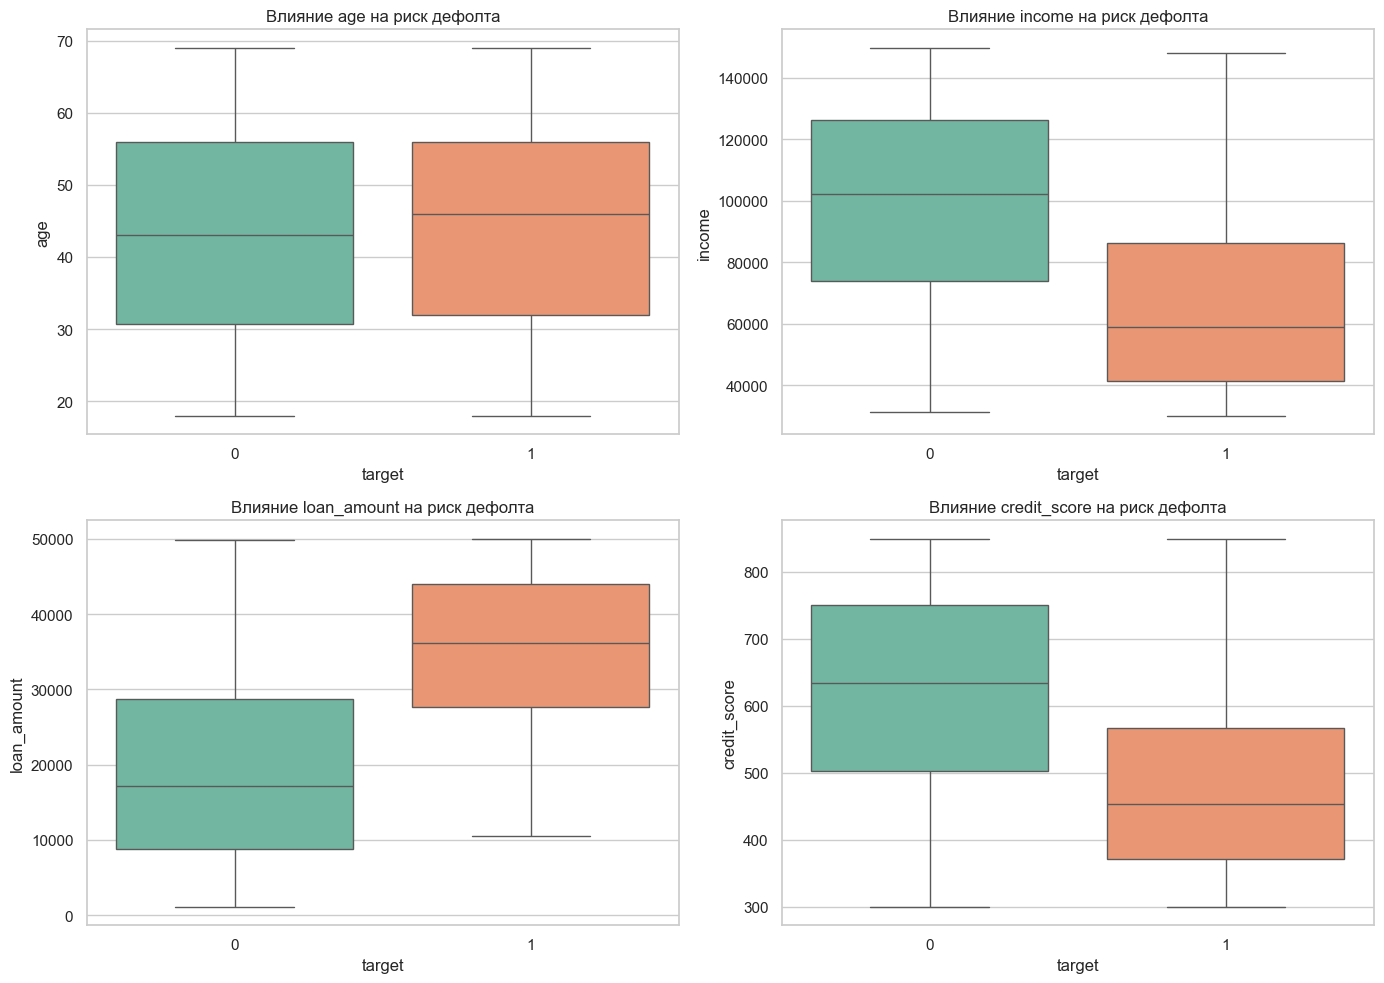

In [3]:
features = ['age', 'income', 'loan_amount', 'credit_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='target', y=feature, ax=axes[row, col], hue='target', palette='Set2', legend=False)
    axes[row, col].set_title(f'Влияние {feature} на риск дефолта')

plt.tight_layout()
plt.show()

In [5]:
print("Пропуски в данных:")
display(df.isnull().sum().to_frame(name='Количество пропусков'))

duplicates = df.duplicated().sum()
print(f"\nКоличество полных дубликатов: {duplicates}")

Пропуски в данных:


,Количество пропусков
age,0
income,0
employment_years,0
loan_amount,0
credit_score,0
target,0



Количество полных дубликатов: 0


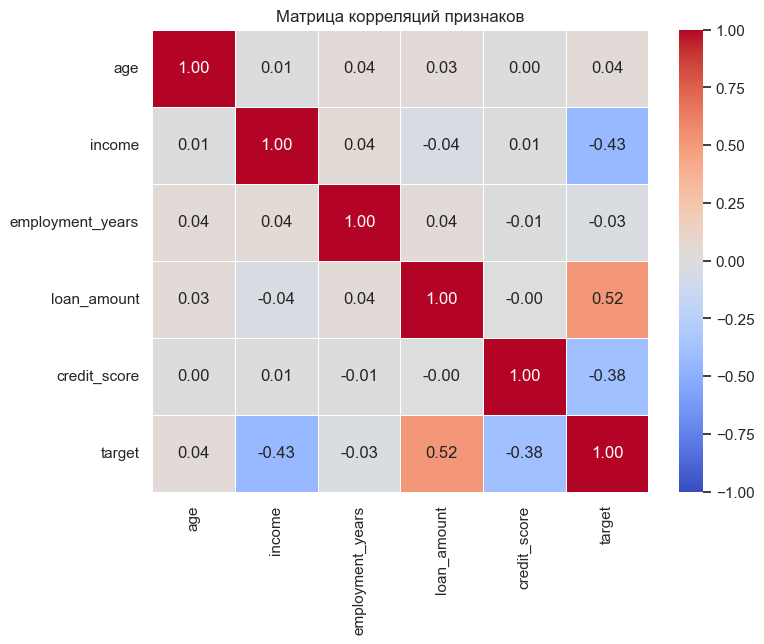

In [9]:
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляций признаков')

plt.savefig(artifacts_dir / "correlation_matrix.png", bbox_inches='tight', dpi=300)

plt.show()

In [7]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

print("Количество выбросов (аномалий) по методу IQR:")
outliers_dict = {col: count_outliers_iqr(df[col]) for col in features}
display(pd.DataFrame.from_dict(outliers_dict, orient='index', columns=['Количество выбросов']))

Количество выбросов (аномалий) по методу IQR:


,Количество выбросов
age,0
income,0
loan_amount,0
credit_score,0
